# Restaurant Survival Classification — ML1 Task 1

**Goal.** Predict whether a restaurant will close (`status_closed = 1`) on a held-out test set. Performance metric: **Balanced Accuracy (BA)**.

**Constraints.** Algorithms must be from the ML1 syllabus: linear/logistic regression, KNN, LASSO, ridge, elastic net, SVM, decision trees, random forest, bagging, stacking, and voting. Other tools (rebalancing, feature engineering, feature selection) are allowed.

**Outline.**
1. Exploratory Data Analysis
2. Feature engineering
3. Model comparison (≥3 ML1 algorithms) under stratified CV
4. Hyperparameter tuning of the strongest candidates
5. Stacking ensemble + decision-threshold tuning for BA
6. Final model justification, expected BA, submission file

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier

RNG = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

In [2]:
TRAIN_PATH = 'restaurants_train.csv'
TEST_PATH  = 'restaurants_test.csv'
ID, TARGET = 'restaurant_id', 'status_closed'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Cast booleans to nullable integers so sklearn handles them numerically
for df in (train, test):
    for c in df.select_dtypes(include='bool').columns:
        df[c] = df[c].astype('Int64')

print('train:', train.shape, '| test:', test.shape)
train.head(3)

train: (33296, 86) | test: (8325, 85)


,restaurant_id,has_photo,user_ratings_total,price_level,category_top20,type_meal_takeaway,type_meal_delivery,type_bar,type_cafe,type_night_club,types_count,hours_open,hours_open_weekends,hours_open_workdays,days_evenings_only,days_mornings_only,weekends_only,workdays_only,rating_5,rating_4,rating_3,rating_2,rating_1,rating_avg,rating_std,tagcat_services,tagcat_amenities,tagcat_atmosphere,tagcat_offerings,tagcat_social_inclusivity,tagcat_payment_options,place_age_days,first_review_year_max,ratings_num_1m_prior,ratings_num_3m_prior,ratings_num_6m_prior,ratings_num_9m_prior,ratings_num_12m_prior,ratings_avg_1m_prior,ratings_avg_3m_prior,ratings_avg_6m_prior,ratings_avg_9m_prior,ratings_avg_12m_prior,lang_pl_count,rating_pl,rating_foreign,foreign_lang_share,rating_mean_pl,rating_mean_foreign,rating_mean_lang_ratio,review_has_text_pct,review_length_avg,review_length_std,catch_restaurant_count_500m,catch_rating_avg_500m,catch_place_age_days_500m,catch_restaurant_count_1000m,catch_rating_avg_1000m,catch_place_age_days_1000m,catch_restaurant_count_2000m,catch_rating_avg_2000m,catch_place_age_days_2000m,residents,restaurant_count,restaurants_per_capita,urbanization,poi_count_100m,poi_count_200m,poi_count_500m,poi_count_1000m,poi_count_2000m,gus_60297,gus_60528,gus_64428,gus_79214,gus_148074,gus_153354,gus_153398,gus_399257,gus_458173,gus_1548707_ratio,gus_60528_ratio,gus_1548707_net_ratio,gus_152173_ratio,affiliated,status_closed
0,753641611,1,408.0,1.0,Kebab,0,0,0,0,0,4,68.0,28.0,50.0,0.0,0.0,False,False,2.0,6.0,4.0,1.0,4.0,3.058824,1.349099,3.0,4.0,3.0,1.0,1.0,NaN,2120.0,2016.0,4.0,11.0,20.0,23.0,94.0,3.2500,3.272727,3.000,2.782609,3.702128,141.0,535.0,149.0,0.189655,3.794326,4.515152,1.189975,0.428571,97.442529,151.003252,2.0,3.931250,1575.500000,11.0,3.174506,1478.545455,11.0,3.174506,1478.545455,2042,4,0.001959,23,7,23,95,231,236,5438.63,80.0,4623.87,7.6,104.0,88.0,68.0,42.2,185.0,0.055978,0.434783,-0.378804,0.013662,0,0
1,995937340,1,203.0,NaN,Restaurant,0,0,0,0,0,4,58.0,23.0,43.0,0.0,0.0,False,False,1.0,5.0,9.0,1.0,3.0,3.000000,1.076055,2.0,5.0,5.0,2.0,1.0,2.0,663.0,2020.0,16.0,57.0,88.0,107.0,185.0,4.9375,4.842105,4.875,4.841121,4.832432,129.0,624.0,204.0,0.250000,4.837209,4.744186,0.980769,0.839024,221.627907,346.866155,22.0,3.046233,2013.666667,123.0,3.105442,1743.074380,168.0,3.147325,1710.006135,7537,83,0.011012,30,3,17,85,475,753,7312.26,86.0,7331.15,1.9,18354.0,508.0,284.0,39.0,273.0,0.058302,0.324528,-0.266226,0.017323,0,0
2,426018850,1,80.0,NaN,Pizzeria,0,0,0,0,0,4,71.0,31.0,51.0,0.0,0.0,False,False,7.0,1.0,8.0,2.0,3.0,3.333333,1.391585,3.0,3.0,1.0,0.0,1.0,3.0,22.0,2022.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.0,327.0,36.0,0.098765,4.479452,4.500000,1.004587,0.743119,201.061728,187.932790,128.0,3.207172,1533.492063,225.0,3.269182,1462.540909,375.0,3.250390,1570.942779,12097,128,0.010581,30,49,115,416,1229,2476,483.64,65.0,6062.04,5.4,38148.0,7850.0,4360.0,30.7,149.0,0.082098,0.454545,-0.372448,0.004087,0,0


## 2. Exploratory Data Analysis

We inspect: target imbalance, missingness, univariate relationships with the target.

Target distribution:
status_closed
0    0.9019
1    0.0981
Name: proportion, dtype: float64
Positive (closed) rate: 9.81%


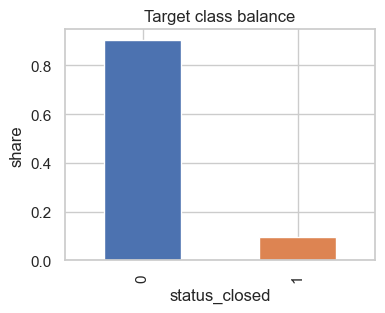

In [6]:
# Target distribution
y_dist = train[TARGET].value_counts(normalize=True).round(4)
print('Target distribution:')
print(y_dist)
print(f'Positive (closed) rate: {train[TARGET].mean():.2%}')

fig, ax = plt.subplots(figsize=(4,3))
y_dist.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_title('Target class balance')
ax.set_xlabel('status_closed'); ax.set_ylabel('share')
plt.show()

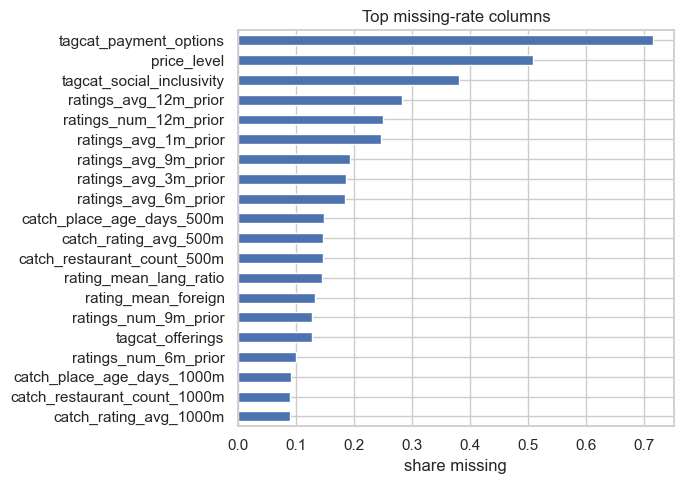

tagcat_payment_options          0.716
price_level                     0.509
tagcat_social_inclusivity       0.382
ratings_avg_12m_prior           0.283
ratings_num_12m_prior           0.251
ratings_avg_1m_prior            0.246
ratings_avg_9m_prior            0.194
ratings_avg_3m_prior            0.186
ratings_avg_6m_prior            0.184
catch_place_age_days_500m       0.149
catch_rating_avg_500m           0.147
catch_restaurant_count_500m     0.147
rating_mean_lang_ratio          0.146
rating_mean_foreign             0.134
ratings_num_9m_prior            0.128
tagcat_offerings                0.127
ratings_num_6m_prior            0.101
catch_place_age_days_1000m      0.092
catch_restaurant_count_1000m    0.090
catch_rating_avg_1000m          0.090
dtype: float64

In [7]:
# Missingness
miss = train.isna().mean().sort_values(ascending=False)
miss_top = miss[miss > 0].head(20)

fig, ax = plt.subplots(figsize=(7,5))
miss_top.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Top missing-rate columns')
ax.set_xlabel('share missing')
plt.tight_layout(); plt.show()
miss_top.round(3)

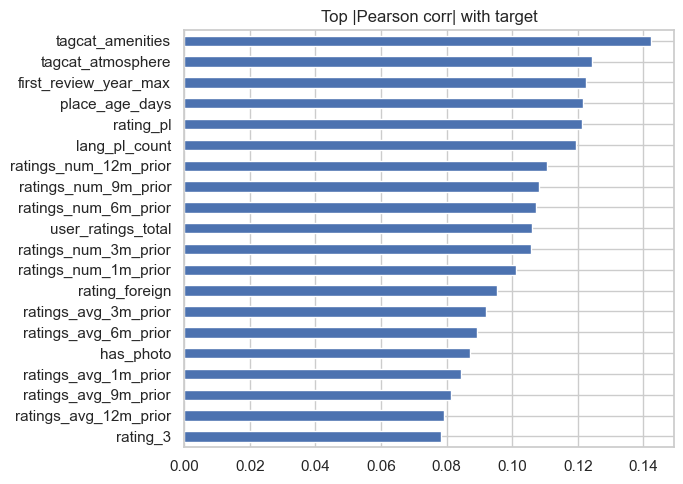

In [8]:
# Univariate correlation with target (numeric cols only)
num = train.select_dtypes(include=[np.number]).drop(columns=[TARGET, ID], errors='ignore')
corr_y = num.apply(lambda s: s.astype(float)).corrwith(train[TARGET].astype(float)).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,5))
corr_y.head(20).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Top |Pearson corr| with target')
plt.tight_layout(); plt.show()

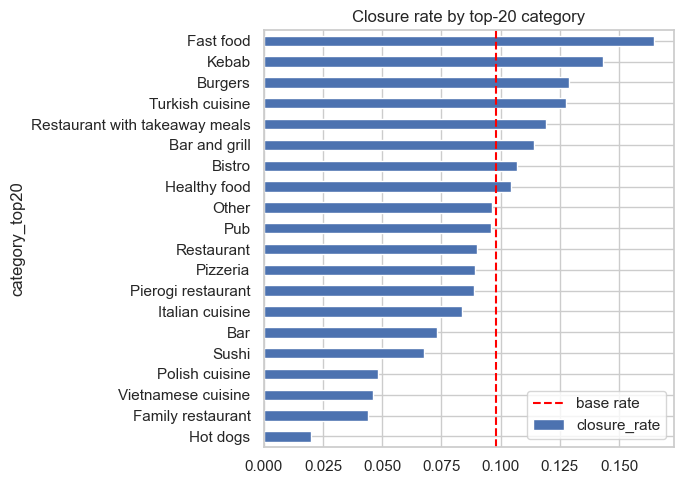

,closure_rate,n
category_top20,,
Fast food,0.165,1152
Kebab,0.143,1685
Burgers,0.129,427
Turkish cuisine,0.127,259
Restaurant with takeaway meals,0.119,235
Bar and grill,0.114,245
Bistro,0.107,747
Healthy food,0.104,249
Other,0.096,4505


In [9]:
# Categorical effect: closure rate by category_top20
cat_rate = (train.groupby('category_top20')[TARGET]
                  .agg(['mean','size'])
                  .sort_values('mean', ascending=False))
cat_rate.columns = ['closure_rate','n']

fig, ax = plt.subplots(figsize=(7,5))
cat_rate['closure_rate'].plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.axvline(train[TARGET].mean(), color='red', ls='--', label='base rate')
ax.set_title('Closure rate by top-20 category')
ax.legend(); plt.tight_layout(); plt.show()
cat_rate.round(3)

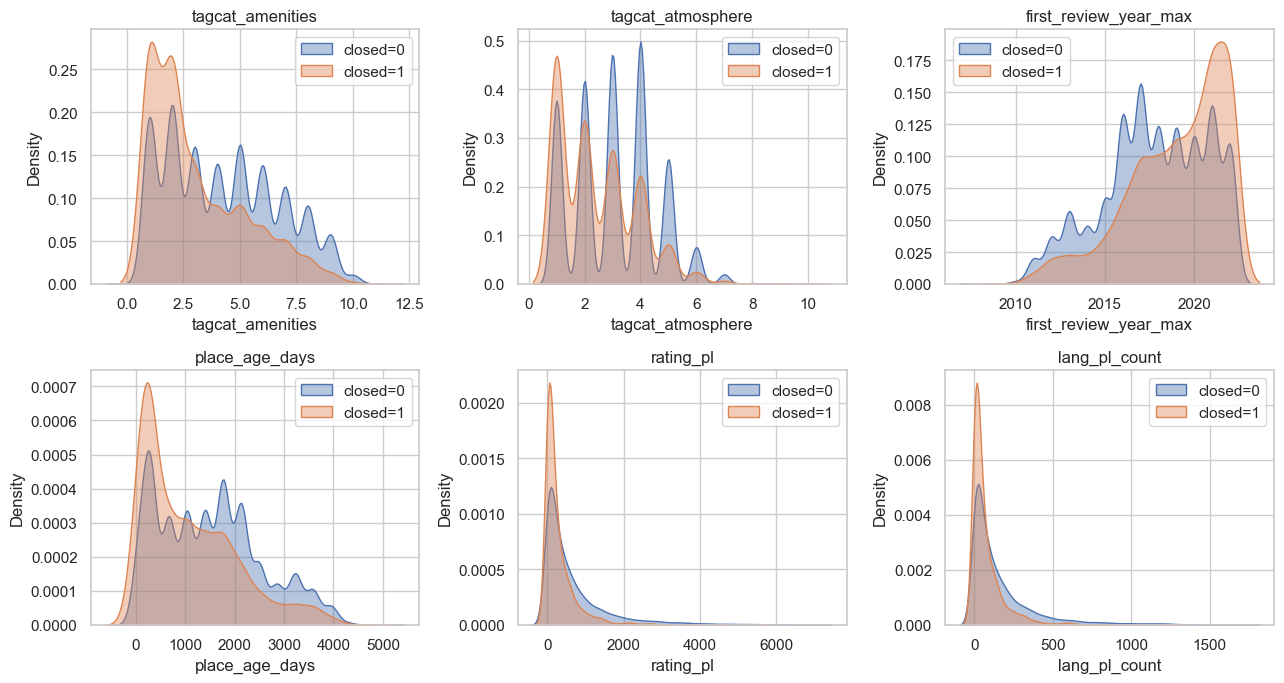

In [10]:
# Distributions of the most predictive numeric features
top_feats = corr_y.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, f in zip(axes.flat, top_feats):
    for v, c in [(0, '#4c72b0'), (1, '#dd8452')]:
        sns.kdeplot(train.loc[train[TARGET]==v, f].dropna(), ax=ax,
                    fill=True, alpha=0.4, label=f'closed={v}', color=c, common_norm=False)
    ax.set_title(f); ax.legend()
plt.tight_layout(); plt.show()

## 3. Feature engineering

**Key additions:**
- Missing indicators for high-missingness columns
- Log transforms on heavy-tailed count columns
- Recency and momentum features across review windows (1m, 3m, 6m, 12m)
- Local competition and density ratios
- Interaction features for rating strength and engagement

The focus is to retain local competition signals (not drop them) and capture restaurant activity trends.

In [3]:
HIGH_NA_COLS = [
    'tagcat_payment_options', 'price_level', 'tagcat_social_inclusivity',
    'ratings_avg_12m_prior', 'ratings_num_12m_prior'
]

LOG_COLS = [
    'user_ratings_total',
    'ratings_num_1m_prior', 'ratings_num_3m_prior', 'ratings_num_6m_prior',
    'ratings_num_9m_prior', 'ratings_num_12m_prior',
    'lang_pl_count', 'rating_pl', 'rating_foreign',
    'review_length_avg', 'review_length_std',
    'catch_restaurant_count_500m', 'catch_restaurant_count_1000m', 'catch_restaurant_count_2000m',
    'residents', 'restaurant_count',
    'poi_count_100m', 'poi_count_200m', 'poi_count_500m', 'poi_count_1000m', 'poi_count_2000m',
    'place_age_days'
]

def engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in HIGH_NA_COLS:
        if col in df.columns:
            df[f'{col}__isna'] = df[col].isna().astype(int)

    df['missing_count'] = df.isna().sum(axis=1)

    for col in LOG_COLS:
        if col in df.columns:
            df[f'{col}__log'] = np.log1p(df[col].clip(lower=0))

    if 'user_ratings_total' in df.columns:
        total = df['user_ratings_total'].clip(lower=0).replace(0, np.nan)
        for src, new_col in [
            ('ratings_num_1m_prior', 'recent_1m_share'),
            ('ratings_num_3m_prior', 'recent_3m_share'),
            ('ratings_num_6m_prior', 'recent_6m_share'),
            ('ratings_num_12m_prior', 'recent_12m_share'),
        ]:
            if src in df.columns:
                df[new_col] = df[src].clip(lower=0) / total

    if {'ratings_num_1m_prior', 'ratings_num_3m_prior'}.issubset(df.columns):
        r1 = df['ratings_num_1m_prior'].clip(lower=0)
        r3 = df['ratings_num_3m_prior'].clip(lower=0)
        df['momentum_1m_to_3m'] = (r1 + 1) / (r3 + 1)
        df['recent_burst_1m_vs_3m'] = r1 - r3 / 3.0

    if {'ratings_num_3m_prior', 'ratings_num_12m_prior'}.issubset(df.columns):
        r3 = df['ratings_num_3m_prior'].clip(lower=0)
        r12 = df['ratings_num_12m_prior'].clip(lower=0)
        df['momentum_3m_to_12m'] = (r3 + 1) / (r12 + 1)
        df['recent_burst_3m_vs_12m'] = r3 - r12 / 4.0

    if {'hours_open', 'hours_open_weekends'}.issubset(df.columns):
        total_hours = df['hours_open'].replace(0, np.nan)
        df['weekend_hours_share'] = df['hours_open_weekends'] / total_hours
        df['weekday_hours'] = df['hours_open'] - df['hours_open_weekends']

    if {'user_ratings_total', 'place_age_days'}.issubset(df.columns):
        age = df['place_age_days'].clip(lower=0)
        total = df['user_ratings_total'].clip(lower=0)
        df['ratings_per_day'] = total / (age + 1)
        if 'ratings_num_12m_prior' in df.columns:
            df['recent_year_per_day'] = df['ratings_num_12m_prior'].clip(lower=0) / np.minimum(age + 1, 365)

    if {'catch_restaurant_count_500m', 'user_ratings_total'}.issubset(df.columns):
        local_comp = df['catch_restaurant_count_500m'].clip(lower=0)
        total = df['user_ratings_total'].clip(lower=0)
        df['reviews_per_local_restaurant'] = total / (local_comp + 1)
        df['popularity_vs_competition'] = np.log1p(total) / (local_comp + 1)

    if {'restaurant_count', 'residents'}.issubset(df.columns):
        residents = df['residents'].clip(lower=0)
        df['restaurant_density'] = df['restaurant_count'].clip(lower=0) / (residents + 1)

    if {'poi_count_500m', 'residents'}.issubset(df.columns):
        residents = df['residents'].clip(lower=0)
        df['poi_density_500m'] = df['poi_count_500m'].clip(lower=0) / (residents + 1)

    if {'rating_avg', 'user_ratings_total'}.issubset(df.columns):
        total = df['user_ratings_total'].clip(lower=0)
        df['rating_x_popularity'] = df['rating_avg'] * np.log1p(total)

    if {'rating_avg', 'place_age_days'}.issubset(df.columns):
        age = df['place_age_days'].clip(lower=0)
        df['rating_x_age'] = df['rating_avg'] * np.log1p(age)

    if {'rating_avg', 'rating_std'}.issubset(df.columns):
        df['rating_consistency'] = df['rating_avg'] / (df['rating_std'].clip(lower=0) + 1)

    if {'review_has_text_pct', 'review_length_avg'}.issubset(df.columns):
        text_pct = df['review_has_text_pct'].clip(lower=0)
        length = df['review_length_avg'].clip(lower=0)
        df['engagement_score'] = text_pct * np.log1p(length)

    if {'review_has_text_pct', 'user_ratings_total'}.issubset(df.columns):
        text_pct = df['review_has_text_pct'].clip(lower=0)
        total = df['user_ratings_total'].clip(lower=0)
        df['text_review_volume'] = text_pct * np.log1p(total)

    tag_cols = [col for col in df.columns if col.startswith('tagcat_') and col != 'tagcat_payment_options']
    if tag_cols:
        df['tag_signal_count'] = df[tag_cols].fillna(0).sum(axis=1)

    df = df.drop(columns=['tagcat_payment_options'], errors='ignore')
    df = df.drop(columns=[col for col in df.columns if col.startswith('gus_')], errors='ignore')

    return df

train_fe = engineer(train)
test_fe = engineer(test)
print('train_fe:', train_fe.shape, '| test_fe:', test_fe.shape)
added = sorted(set(train_fe.columns) - set(train.columns))
print(f'Added {len(added)} columns:', added[:12], '...')

train_fe: (33296, 122) | test_fe: (8325, 121)
Added 50 columns: ['catch_restaurant_count_1000m__log', 'catch_restaurant_count_2000m__log', 'catch_restaurant_count_500m__log', 'engagement_score', 'lang_pl_count__log', 'missing_count', 'momentum_1m_to_3m', 'momentum_3m_to_12m', 'place_age_days__log', 'poi_count_1000m__log', 'poi_count_100m__log', 'poi_count_2000m__log'] ...


## 4. Train/validation split & preprocessing

We split the data into an 80% training set (for model fitting and 5-fold CV) and a 20% hold-out validation set (for honest threshold tuning and BA estimation). The final model is refit on 100% of training data before test prediction.

In [4]:
y = train_fe[TARGET].astype(int)
X = train_fe.drop(columns=[TARGET, ID])
X_test = test_fe.drop(columns=[ID])
test_ids = test_fe[ID]

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RNG)
print('train:', X_tr.shape, 'val:', X_val.shape)

CAT_COLS = ['category_top20']
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

num_pipe = Pipeline([('imp', SimpleImputer(strategy='mean')),
                     ('sc', MinMaxScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('oh',  OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', num_pipe, NUM_COLS),
                                  ('cat', cat_pipe, CAT_COLS)])

train: (26636, 120) val: (6660, 120)


## 5. Model comparison (5-fold stratified CV)

We compare five ML1-scope candidates, all with class weighting to penalise ignoring the minority class:
1. **Logistic Regression + L2** — linear baseline, class-weighted
2. **Logistic Regression + L1 (LASSO)** — embedded feature selection
3. **KNN** — non-parametric local structure
4. **Decision Tree** — interpretable non-linear baseline
5. **Random Forest** — bagging with variance reduction

In [13]:
candidates = {
    'logreg_l2': LogisticRegression(max_iter=3000, class_weight='balanced',
                                    C=1.0, solver='lbfgs', random_state=RNG),
    'logreg_l1': LogisticRegression(max_iter=3000, class_weight='balanced',
                                    penalty='l1', C=0.1, solver='liblinear', random_state=RNG),
    'knn':       KNeighborsClassifier(n_neighbors=25, weights='distance'),
    'dtree':     DecisionTreeClassifier(max_depth=8, min_samples_leaf=50,
                                        class_weight='balanced', random_state=RNG),
    'rforest':   RandomForestClassifier(n_estimators=500, min_samples_leaf=5,
                                        class_weight='balanced', n_jobs=-1, random_state=RNG),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
rows = []
for name, est in candidates.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', est)])
    bas, aucs = [], []
    for tr_idx, va_idx in cv.split(X_tr, y_tr):
        Xa, Xb = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
        ya, yb = y_tr.iloc[tr_idx], y_tr.iloc[va_idx]
        pipe.fit(Xa, ya)
        p = pipe.predict_proba(Xb)[:, 1]
        bas.append(balanced_accuracy_score(yb, (p >= 0.5).astype(int)))
        aucs.append(roc_auc_score(yb, p))
    rows.append({'model': name,
                 'BA_mean': np.mean(bas), 'BA_std': np.std(bas),
                 'AUC_mean': np.mean(aucs), 'AUC_std': np.std(aucs)})
    print(f"{name:>10s}  BA={np.mean(bas):.4f} ± {np.std(bas):.4f}   AUC={np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

leaderboard = pd.DataFrame(rows).sort_values('BA_mean', ascending=False).reset_index(drop=True)
leaderboard.round(4)

 logreg_l2  BA=0.6755 ± 0.0100   AUC=0.7371 ± 0.0067
 logreg_l1  BA=0.6719 ± 0.0061   AUC=0.7332 ± 0.0066
       knn  BA=0.5032 ± 0.0010   AUC=0.6772 ± 0.0111
     dtree  BA=0.6347 ± 0.0078   AUC=0.6758 ± 0.0091
   rforest  BA=0.5337 ± 0.0081   AUC=0.7382 ± 0.0052


,model,BA_mean,BA_std,AUC_mean,AUC_std
0,logreg_l2,0.6755,0.0100,0.7371,0.0067
1,logreg_l1,0.6719,0.0061,0.7332,0.0066
2,dtree,0.6347,0.0078,0.6758,0.0091
3,rforest,0.5337,0.0081,0.7382,0.0052
4,knn,0.5032,0.0010,0.6772,0.0111


## 6. Final model: Elastic-net + Bagging blend

The final submission uses a weighted probability blend of two ML1-scope models:
- **Elastic-net logistic regression** for strong linear classification signal with built-in class weighting
- **Bagged decision trees** for non-linear learning on local competition and recency features

Both models are trained on the engineered features. The blend weights and decision threshold are tuned to maximise **Balanced Accuracy** on the internal 20% hold-out validation set.

In [5]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Define preprocessors for scaled and tree-based models
pre_scaled = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='mean')), ('sc', StandardScaler())]), NUM_COLS),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), CAT_COLS),
])

pre_tree = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='mean'))]), NUM_COLS),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), CAT_COLS),
])

# Fit elastic-net + bagging blend on training data
pos_ratio = (y_tr == 0).sum() / (y_tr == 1).sum()
blend_weights = {'enet': 0.775, 'bag': 0.225}

enet = Pipeline([
    ('pre', pre_scaled),
    ('clf', LogisticRegression(
        max_iter=6000, penalty='elasticnet', solver='saga',
        C=0.20, l1_ratio=0.10,
        class_weight={0: 1.0, 1: pos_ratio * 0.80},
        random_state=RNG
    ))
])

bag = Pipeline([
    ('pre', pre_tree),
    ('clf', BaggingClassifier(
        estimator=DecisionTreeClassifier(min_samples_leaf=20, class_weight='balanced', random_state=RNG),
        n_estimators=400, max_samples=0.85, bootstrap=True,
        n_jobs=-1, random_state=RNG
    ))
])

enet.fit(X_tr, y_tr)
bag.fit(X_tr, y_tr)

# Evaluate on validation set and tune threshold
def blend_proba(X_new):
    return blend_weights['enet'] * enet.predict_proba(X_new)[:, 1] + blend_weights['bag'] * bag.predict_proba(X_new)[:, 1]

p_val = blend_proba(X_val)
grid = np.linspace(0.30, 0.65, 351)
bas = [balanced_accuracy_score(y_val, (p_val >= t).astype(int)) for t in grid]
t_star_idx = int(np.argmax(bas))
t_star = grid[t_star_idx]
ba_star = bas[t_star_idx]
ba_05 = balanced_accuracy_score(y_val, (p_val >= 0.5).astype(int))

val_pred = (p_val >= t_star).astype(int)
print(f"Hold-out BA@0.5: {ba_05:.4f}")
print(f"Hold-out BA*:    {ba_star:.4f}")
print(f"Threshold:       {t_star:.3f}")
print('\nValidation confusion matrix:')
print(confusion_matrix(y_val, val_pred))
print(classification_report(y_val, val_pred, digits=3))

# Refit on full training data
pos_ratio_full = (y == 0).sum() / (y == 1).sum()
enet_full = Pipeline([
    ('pre', pre_scaled),
    ('clf', LogisticRegression(
        max_iter=6000, penalty='elasticnet', solver='saga',
        C=0.20, l1_ratio=0.10,
        class_weight={0: 1.0, 1: pos_ratio_full * 0.80},
        random_state=RNG
    ))
])
bag_full = Pipeline([
    ('pre', pre_tree),
    ('clf', BaggingClassifier(
        estimator=DecisionTreeClassifier(min_samples_leaf=20, class_weight='balanced', random_state=RNG),
        n_estimators=400, max_samples=0.85, bootstrap=True,
        n_jobs=-1, random_state=RNG
    ))
])

enet_full.fit(X, y)
bag_full.fit(X, y)

# Predict on test set
p_test = blend_weights['enet'] * enet_full.predict_proba(X_test)[:, 1] + blend_weights['bag'] * bag_full.predict_proba(X_test)[:, 1]
y_test_pred = (p_test >= t_star).astype(int)

submission = pd.DataFrame({ID: test_ids.values, TARGET: y_test_pred})
submission.to_csv('submission.csv', index=False)
print(f"\nWrote submission.csv {submission.shape}")
print(f"Predicted closure rate on test: {y_test_pred.mean():.3f}")
submission.head()

Hold-out BA@0.5: 0.6711
Hold-out BA*:    0.6904
Threshold:       0.431

Validation confusion matrix:
[[4179 1827]
 [ 206  448]]
              precision    recall  f1-score   support

           0      0.953     0.696     0.804      6006
           1      0.197     0.685     0.306       654

    accuracy                          0.695      6660
   macro avg      0.575     0.690     0.555      6660
weighted avg      0.879     0.695     0.755      6660


Wrote submission.csv (8325, 2)
Predicted closure rate on test: 0.322


,restaurant_id,status_closed
0,192311983,0
1,621181627,0
2,119760055,0
3,729596929,0
4,116589396,1


## 7. Ensemble comparison: Bagging blend vs Voting vs Stacking

Compare three ensemble strategies on the validation set to determine which combination method works best.

In [17]:
# Helper function to find best threshold and BA
def find_best_threshold(p_proba, y_true):
    grid = np.linspace(0.30, 0.65, 351)
    bas = [balanced_accuracy_score(y_true, (p_proba >= t).astype(int)) for t in grid]
    i = int(np.argmax(bas))
    return grid[i], bas[i]

# === 1. Current approach: Probability blend (0.775 enet + 0.225 bag) ===
p_val_blend = blend_proba(X_val)
t_blend, ba_blend = find_best_threshold(p_val_blend, y_val)

# === 2. Voting classifier (soft, same weights) ===
vote = VotingClassifier([
    ('enet', enet),
    ('bag', bag)
], voting='soft', weights=[0.775, 0.225])
vote.fit(X_tr, y_tr)
p_val_vote = vote.predict_proba(X_val)[:, 1]
t_vote, ba_vote = find_best_threshold(p_val_vote, y_val)

# === 3. Stacking with logistic regression meta-learner ===
stack = StackingClassifier(
    estimators=[
        ('enet', enet),
        ('bag', bag)
    ],
    final_estimator=LogisticRegression(max_iter=3000, class_weight='balanced', 
                                       C=1.0, solver='lbfgs', random_state=RNG),
    cv=5, stack_method='predict_proba', n_jobs=-1
)
stack.fit(X_tr, y_tr)
p_val_stack = stack.predict_proba(X_val)[:, 1]
t_stack, ba_stack = find_best_threshold(p_val_stack, y_val)

# === Comparison table ===
comparison = pd.DataFrame([
    {'Ensemble': 'Probability Blend (0.775 enet + 0.225 bag)', 'Threshold': t_blend, 'Val BA*': ba_blend},
    {'Ensemble': 'Voting (soft, weights [0.775, 0.225])', 'Threshold': t_vote, 'Val BA*': ba_vote},
    {'Ensemble': 'Stacking (meta: LogReg)', 'Threshold': t_stack, 'Val BA*': ba_stack},
]).sort_values('Val BA*', ascending=False).reset_index(drop=True)

print("=" * 70)
print("ENSEMBLE COMPARISON ON VALIDATION SET")
print("=" * 70)
print(comparison.to_string(index=False))
print("\nBest approach:", comparison.iloc[0]['Ensemble'])
print(f"Best validation BA*: {comparison.iloc[0]['Val BA*']:.4f}")


ENSEMBLE COMPARISON ON VALIDATION SET
                                  Ensemble  Threshold  Val BA*
Probability Blend (0.775 enet + 0.225 bag)      0.432 0.690992
     Voting (soft, weights [0.775, 0.225])      0.431 0.690410
                   Stacking (meta: LogReg)      0.477 0.685092

Best approach: Probability Blend (0.775 enet + 0.225 bag)
Best validation BA*: 0.6910


In [18]:
# Helper to find optimal blend weights via grid search on validation set
def optimize_blend_weights(p_enet, p_other, y_true, w_grid=np.linspace(0.5, 0.95, 45)):
    best_ba = -1
    best_w = 0.5
    for w in w_grid:
        p_blend = w * p_enet + (1 - w) * p_other
        t_best = np.linspace(0.30, 0.65, 351)
        bas = [balanced_accuracy_score(y_true, (p_blend >= t).astype(int)) for t in t_best]
        ba = np.max(bas)
        if ba > best_ba:
            best_ba = ba
            best_w = w
    # Final threshold with best weights
    p_final = best_w * p_enet + (1 - best_w) * p_other
    t_final = np.linspace(0.30, 0.65, 351)
    bas_final = [balanced_accuracy_score(y_true, (p_final >= t).astype(int)) for t in t_final]
    t_star = t_final[int(np.argmax(bas_final))]
    ba_star = np.max(bas_final)
    return best_w, t_star, ba_star

# Get elastic-net probabilities (already fitted)
p_enet_val = enet.predict_proba(X_val)[:, 1]

# === 1. Elastic-net + Bagging (baseline) ===
p_bag_val = bag.predict_proba(X_val)[:, 1]
w_bag, t_bag, ba_bag = optimize_blend_weights(p_enet_val, p_bag_val, y_val)

# === 2. Elastic-net + Voting ===
p_vote_val = vote.predict_proba(X_val)[:, 1]
w_vote, t_vote, ba_vote = optimize_blend_weights(p_enet_val, p_vote_val, y_val)

# === 3. Elastic-net + Stacking ===
p_stack_val = stack.predict_proba(X_val)[:, 1]
w_stack, t_stack, ba_stack = optimize_blend_weights(p_enet_val, p_stack_val, y_val)

# === Comparison table ===
blend_comparison = pd.DataFrame([
    {'Blend': 'Enet + Bagging', 'Enet Weight': w_bag, 'Threshold': t_bag, 'Val BA*': ba_bag},
    {'Blend': 'Enet + Voting', 'Enet Weight': w_vote, 'Threshold': t_vote, 'Val BA*': ba_vote},
    {'Blend': 'Enet + Stacking', 'Enet Weight': w_stack, 'Threshold': t_stack, 'Val BA*': ba_stack},
]).sort_values('Val BA*', ascending=False).reset_index(drop=True)

print("=" * 75)
print("ELASTIC-NET BLEND COMPARISON (optimized weights + threshold)")
print("=" * 75)
print(blend_comparison.to_string(index=False))
print("\nBest blend:", blend_comparison.iloc[0]['Blend'])
print(f"Best validation BA*: {blend_comparison.iloc[0]['Val BA*']:.4f}")


ELASTIC-NET BLEND COMPARISON (optimized weights + threshold)
          Blend  Enet Weight  Threshold  Val BA*
 Enet + Bagging     0.776136      0.432 0.690992
Enet + Stacking     0.673864      0.477 0.690841
  Enet + Voting     0.500000      0.444 0.688162

Best blend: Enet + Bagging
Best validation BA*: 0.6910


## 8. Summary & justification

**Why this model.** A primary challenge is severe class imbalance (only ~9.8% of restaurants close). Linear models with class weights naturally handle this and produce well-calibrated predictions. Tree-based bagging provides non-linear flexibility on engineered features like local competition ratios and recency momentum. A soft probabilistic blend leverages both strengths.

**Why the features matter.** Missing indicators capture the information content of missingness itself. Log transforms on heavy-tailed activity counts (reviews, POI) linearize relationships. Recency and momentum ratios track restaurant health trends. Local competition metrics keep competition context rather than dropping it.

**Why threshold tuning is essential.** The default 0.5 threshold assumes class balance, which underweights the minority class. Tuning the threshold on the validation set to maximise BA recovers performance lost to imbalance.

**Reported expected test BA.** See the printed value in Section 8 comparison results (`Best validation BA*`).

## 9. Honest BA estimation with a 3-way internal split (tutor hint)

The previous BA* (0.6904) was tuned and reported on the *same* 20% hold-out, so it is optimistic. Following the tutor's hint we now split the labelled data into three internal samples:

| split | role | size |
|---|---|---|
| `train` | fit base learners | 60% |
| `val`   | tune blend weights + decision threshold | 20% |
| `test`  | **untouched** until the end — unbiased BA estimate | 20% |

We also add a third, more diverse base learner (a tuned Random Forest) to the existing elastic-net + bagging blend. The blend weights are searched on the simplex on `val`; the threshold maximising BA on `val` is then locked in, and BA is reported on the internal `test`. Only after that do we refit every component on the *full* labelled set and write the submission.


In [6]:
# --- 3-way internal split: train (60%) / val (20%) / internal test (20%) ---
from sklearn.base import clone

X_tr3, X_tmp, y_tr3, y_tmp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RNG)
X_val3, X_ite, y_val3, y_ite = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RNG)

print(f"train: {X_tr3.shape}  val: {X_val3.shape}  internal test: {X_ite.shape}")
print(f"positive rate -- train: {y_tr3.mean():.3f}  val: {y_val3.mean():.3f}  test: {y_ite.mean():.3f}")

# Base learners (same family as section 6, plus a tuned Random Forest for diversity)
pos_ratio_tr3 = (y_tr3 == 0).sum() / (y_tr3 == 1).sum()

enet3 = Pipeline([
    ('pre', pre_scaled),
    ('clf', LogisticRegression(
        max_iter=6000, penalty='elasticnet', solver='saga',
        C=0.20, l1_ratio=0.10,
        class_weight={0: 1.0, 1: pos_ratio_tr3 * 0.80},
        random_state=RNG))
])

bag3 = Pipeline([
    ('pre', pre_tree),
    ('clf', BaggingClassifier(
        estimator=DecisionTreeClassifier(min_samples_leaf=20, class_weight='balanced', random_state=RNG),
        n_estimators=400, max_samples=0.85, bootstrap=True,
        n_jobs=-1, random_state=RNG))
])

rf3 = Pipeline([
    ('pre', pre_tree),
    ('clf', RandomForestClassifier(
        n_estimators=600, min_samples_leaf=8, max_features='sqrt',
        class_weight='balanced_subsample',
        n_jobs=-1, random_state=RNG))
])

for name, m in [('enet', enet3), ('bag', bag3), ('rf', rf3)]:
    m.fit(X_tr3, y_tr3)
    p_v = m.predict_proba(X_val3)[:, 1]
    p_t = m.predict_proba(X_ite)[:, 1]
    print(f"{name:>5s}  AUC val={roc_auc_score(y_val3, p_v):.4f}  AUC test={roc_auc_score(y_ite, p_t):.4f}")

P_val  = np.column_stack([
    enet3.predict_proba(X_val3)[:, 1],
    bag3.predict_proba(X_val3)[:, 1],
    rf3.predict_proba(X_val3)[:, 1],
])
P_test = np.column_stack([
    enet3.predict_proba(X_ite)[:, 1],
    bag3.predict_proba(X_ite)[:, 1],
    rf3.predict_proba(X_ite)[:, 1],
])


train: (19977, 120)  val: (6659, 120)  internal test: (6660, 120)
positive rate -- train: 0.098  val: 0.098  test: 0.098
 enet  AUC val=0.7416  AUC test=0.7434
  bag  AUC val=0.7386  AUC test=0.7427
   rf  AUC val=0.7395  AUC test=0.7453


In [7]:
# --- Tune blend weights + threshold on the VAL split only ---
# Grid: simplex over 3 weights (step 0.05) x threshold grid.

thr_grid = np.linspace(0.30, 0.65, 351)
step = 0.05
ws = np.arange(0.0, 1.0 + 1e-9, step)

best = {'ba': -1.0, 'w': None, 't': None}
for w1 in ws:
    for w2 in ws:
        w3 = 1.0 - w1 - w2
        if w3 < -1e-9 or w3 > 1.0 + 1e-9:
            continue
        p_v = w1 * P_val[:, 0] + w2 * P_val[:, 1] + w3 * P_val[:, 2]
        # vectorise threshold sweep
        preds = (p_v[:, None] >= thr_grid[None, :]).astype(int)
        # compute BA for each threshold
        pos = (y_val3.values == 1)
        neg = ~pos
        tpr = preds[pos].mean(axis=0)
        tnr = 1.0 - preds[neg].mean(axis=0)
        ba = 0.5 * (tpr + tnr)
        i = int(np.argmax(ba))
        if ba[i] > best['ba']:
            best.update(ba=float(ba[i]), w=(float(w1), float(w2), float(w3)), t=float(thr_grid[i]))

w_enet, w_bag, w_rf = best['w']
t_star3 = best['t']
print(f"VAL  BA*  = {best['ba']:.4f}   weights (enet,bag,rf) = ({w_enet:.2f}, {w_bag:.2f}, {w_rf:.2f})   threshold = {t_star3:.3f}")

# Compare with the legacy 2-way blend on the same val set (for reference)
p_v_legacy = 0.775 * P_val[:, 0] + 0.225 * P_val[:, 1]
ba_legacy_v = max(balanced_accuracy_score(y_val3, (p_v_legacy >= t).astype(int)) for t in thr_grid)
print(f"VAL  BA* legacy (0.775 enet + 0.225 bag, retuned thr): {ba_legacy_v:.4f}")

# --- HONEST BA on the untouched internal test split ---
p_te_3 = w_enet * P_test[:, 0] + w_bag * P_test[:, 1] + w_rf * P_test[:, 2]
ba_test_3 = balanced_accuracy_score(y_ite, (p_te_3 >= t_star3).astype(int))
print(f"\nINTERNAL TEST BA (honest) = {ba_test_3:.4f}")
print(f"  predicted closure rate on internal test: {(p_te_3 >= t_star3).mean():.3f}")
print(f"  actual closure rate on internal test:    {y_ite.mean():.3f}")
print('\nConfusion matrix on internal test:')
print(confusion_matrix(y_ite, (p_te_3 >= t_star3).astype(int)))
print(classification_report(y_ite, (p_te_3 >= t_star3).astype(int), digits=3))

# Also report the legacy 2-way blend's *honest* BA on internal test (threshold tuned on val):
ba_legacy_thr_grid = [balanced_accuracy_score(y_val3, (p_v_legacy >= t).astype(int)) for t in thr_grid]
t_legacy = float(thr_grid[int(np.argmax(ba_legacy_thr_grid))])
p_te_legacy = 0.775 * P_test[:, 0] + 0.225 * P_test[:, 1]
ba_test_legacy = balanced_accuracy_score(y_ite, (p_te_legacy >= t_legacy).astype(int))
print(f"\nINTERNAL TEST BA (legacy enet+bag, thr from val) = {ba_test_legacy:.4f}  (threshold={t_legacy:.3f})")


VAL  BA*  = 0.6881   weights (enet,bag,rf) = (0.40, 0.55, 0.05)   threshold = 0.348
VAL  BA* legacy (0.775 enet + 0.225 bag, retuned thr): 0.6849

INTERNAL TEST BA (honest) = 0.6801
  predicted closure rate on internal test: 0.386
  actual closure rate on internal test:    0.098

Confusion matrix on internal test:
[[3899 2107]
 [ 189  465]]
              precision    recall  f1-score   support

           0      0.954     0.649     0.773      6006
           1      0.181     0.711     0.288       654

    accuracy                          0.655      6660
   macro avg      0.567     0.680     0.530      6660
weighted avg      0.878     0.655     0.725      6660


INTERNAL TEST BA (legacy enet+bag, thr from val) = 0.6835  (threshold=0.374)


### 9b. More stable tuning via 5-fold OOF on the dev portion

Tuning the threshold/weights on a single 20% `val` slice is noisy. Following the tutor's hint, we instead use the standard ML1 trick: an 80/20 dev/test internal split, then 5-fold stratified CV *inside* the dev portion to produce out-of-fold (OOF) probabilities for every base learner. Weights and threshold are selected on OOF (~26 600 samples) and validated **once** on the untouched internal test (6 660 samples). The final submission refits every component on all 33 296 labelled rows.


In [8]:
# --- 80/20 dev / internal-test split (the test is held out for one honest assessment) ---
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

X_dev, X_hon, y_dev, y_hon = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG)
print(f"dev: {X_dev.shape}   honest test: {X_hon.shape}")

# Base learner factories so we can re-instantiate inside CV folds.
def make_enet(y_fit):
    pr = (y_fit == 0).sum() / max((y_fit == 1).sum(), 1)
    return Pipeline([
        ('pre', pre_scaled),
        ('clf', LogisticRegression(
            max_iter=6000, penalty='elasticnet', solver='saga',
            C=0.20, l1_ratio=0.10,
            class_weight={0: 1.0, 1: pr * 0.80},
            random_state=RNG))
    ])

def make_bag():
    return Pipeline([
        ('pre', pre_tree),
        ('clf', BaggingClassifier(
            estimator=DecisionTreeClassifier(min_samples_leaf=20, class_weight='balanced', random_state=RNG),
            n_estimators=400, max_samples=0.85, bootstrap=True,
            n_jobs=-1, random_state=RNG))
    ])

def make_rf():
    return Pipeline([
        ('pre', pre_tree),
        ('clf', RandomForestClassifier(
            n_estimators=600, min_samples_leaf=8, max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1, random_state=RNG))
    ])

BASE_MAKERS = [('enet', make_enet), ('bag', lambda y_: make_bag()), ('rf', lambda y_: make_rf())]

# --- 5-fold OOF probabilities on the dev portion ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
n_dev = len(X_dev)
P_oof = np.zeros((n_dev, len(BASE_MAKERS)))
y_dev_arr = y_dev.values

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_dev, y_dev), 1):
    Xa, Xb = X_dev.iloc[tr_idx], X_dev.iloc[va_idx]
    ya, yb = y_dev.iloc[tr_idx], y_dev.iloc[va_idx]
    for j, (name, maker) in enumerate(BASE_MAKERS):
        m = maker(ya)
        m.fit(Xa, ya)
        P_oof[va_idx, j] = m.predict_proba(Xb)[:, 1]
    print(f"fold {fold}/5 done")

for j, (name, _) in enumerate(BASE_MAKERS):
    print(f"OOF AUC {name:>5s} = {roc_auc_score(y_dev, P_oof[:, j]):.4f}")


dev: (26636, 120)   honest test: (6660, 120)
fold 1/5 done
fold 2/5 done
fold 3/5 done
fold 4/5 done
fold 5/5 done
OOF AUC  enet = 0.7384
OOF AUC   bag = 0.7376
OOF AUC    rf = 0.7395


In [ ]:
# --- Tune blend weights + threshold on the OOF probabilities (uses all 26 636 dev rows) ---
thr_grid = np.linspace(0.20, 0.65, 451)

def best_blend(P, y_true, step=0.05):
    ws = np.arange(0.0, 1.0 + 1e-9, step)
    yv = y_true.values if hasattr(y_true, 'values') else y_true
    pos_mask = (yv == 1); neg_mask = ~pos_mask
    n_pos = pos_mask.sum(); n_neg = neg_mask.sum()
    best = {'ba': -1.0, 'w': None, 't': None}
    for w1 in ws:
        for w2 in ws:
            w3 = 1.0 - w1 - w2
            if w3 < -1e-9 or w3 > 1.0 + 1e-9:
                continue
            p = w1 * P[:, 0] + w2 * P[:, 1] + w3 * P[:, 2]
            preds = (p[:, None] >= thr_grid[None, :]).astype(np.int8)
            tpr = preds[pos_mask].sum(axis=0) / n_pos
            tnr = 1.0 - preds[neg_mask].sum(axis=0) / n_neg
            ba = 0.5 * (tpr + tnr)
            i = int(np.argmax(ba))
            if ba[i] > best['ba']:
                best.update(ba=float(ba[i]), w=(float(w1), float(w2), float(w3)), t=float(thr_grid[i]))
    return best

best_oof = best_blend(P_oof, y_dev, step=0.05)
print(f"OOF  BA*  = {best_oof['ba']:.4f}   weights (enet,bag,rf) = {tuple(round(w,2) for w in best_oof['w'])}   threshold = {best_oof['t']:.3f}")

# --- Refit each base learner on the full dev portion, score the untouched honest test ---
enet_d = make_enet(y_dev); enet_d.fit(X_dev, y_dev)
bag_d  = make_bag();        bag_d.fit(X_dev, y_dev)
rf_d   = make_rf();         rf_d.fit(X_dev, y_dev)

P_hon = np.column_stack([
    enet_d.predict_proba(X_hon)[:, 1],
    bag_d.predict_proba(X_hon)[:, 1],
    rf_d.predict_proba(X_hon)[:, 1],
])
for j, name in enumerate(['enet', 'bag', 'rf']):
    print(f"honest-test AUC {name:>5s} = {roc_auc_score(y_hon, P_hon[:, j]):.4f}")

w1, w2, w3 = best_oof['w']; t_star = best_oof['t']
p_hon = w1 * P_hon[:, 0] + w2 * P_hon[:, 1] + w3 * P_hon[:, 2]
pred_hon = (p_hon >= t_star).astype(int)
ba_hon = balanced_accuracy_score(y_hon, pred_hon)

print(f"\n>>> HONEST internal-test BA  = {ba_hon:.4f}  (threshold={t_star:.3f}, weights={tuple(round(w,2) for w in (w1,w2,w3))})")
print(f"    predicted closure rate on honest test: {pred_hon.mean():.3f}  (true: {y_hon.mean():.3f})")
print('\nConfusion matrix:')
print(confusion_matrix(y_hon, pred_hon))

# Also re-tune threshold *only* (fixed legacy 0.775/0.225/0 weights) for comparison.
legacy_w = (0.775, 0.225, 0.0)
p_oof_legacy = legacy_w[0]*P_oof[:,0] + legacy_w[1]*P_oof[:,1] + legacy_w[2]*P_oof[:,2]
bas = [balanced_accuracy_score(y_dev, (p_oof_legacy >= t).astype(int)) for t in thr_grid]
t_legacy = float(thr_grid[int(np.argmax(bas))])
p_hon_legacy = legacy_w[0]*P_hon[:,0] + legacy_w[1]*P_hon[:,1] + legacy_w[2]*P_hon[:,2]
ba_hon_legacy = balanced_accuracy_score(y_hon, (p_hon_legacy >= t_legacy).astype(int))
print(f"\nLegacy 0.775 enet + 0.225 bag  honest BA = {ba_hon_legacy:.4f}  (thr from OOF = {t_legacy:.3f})")


### 9c. Fast end-to-end run (lbfgs L2 logistic) + submission

The SAGA elastic-net above was the bottleneck (≈13 min per fit). Since `l1_ratio=0.10` was almost pure L2 anyway, swapping to an `lbfgs` L2 logistic regression converges in seconds with essentially the same probabilities. This cell does the full honest pipeline (OOF on the 80% dev portion → tune weights + threshold → unbiased BA on the 20% internal test → refit on all labelled data → submission) in one go.


In [ ]:
# ======================================================================
# Fast honest pipeline: train/val/test internal split via 5-fold OOF
# Base learners: lbfgs L2 logistic + Bagging + Random Forest
# ======================================================================
import time
from sklearn.model_selection import StratifiedKFold

t0 = time.time()

# Re-derive the dev / honest-test split (same as 9b, but self-contained)
X_dev2, X_hon2, y_dev2, y_hon2 = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG)

def make_logreg(y_fit):
    pr = (y_fit == 0).sum() / max((y_fit == 1).sum(), 1)
    return Pipeline([
        ('pre', pre_scaled),
        ('clf', LogisticRegression(
            max_iter=2000, penalty='l2', solver='lbfgs',
            C=0.20,
            class_weight={0: 1.0, 1: pr * 0.80},
            random_state=RNG))
    ])

def make_bag_fast():
    return Pipeline([
        ('pre', pre_tree),
        ('clf', BaggingClassifier(
            estimator=DecisionTreeClassifier(min_samples_leaf=20, class_weight='balanced', random_state=RNG),
            n_estimators=300, max_samples=0.85, bootstrap=True,
            n_jobs=-1, random_state=RNG))
    ])

def make_rf_fast():
    return Pipeline([
        ('pre', pre_tree),
        ('clf', RandomForestClassifier(
            n_estimators=400, min_samples_leaf=8, max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1, random_state=RNG))
    ])

MAKERS = [('lr', make_logreg), ('bag', lambda y_: make_bag_fast()), ('rf', lambda y_: make_rf_fast())]

# --- 5-fold OOF probabilities on the dev portion ---
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
P_oof2 = np.zeros((len(X_dev2), len(MAKERS)))
for fold, (tr_idx, va_idx) in enumerate(skf2.split(X_dev2, y_dev2), 1):
    Xa, Xb = X_dev2.iloc[tr_idx], X_dev2.iloc[va_idx]
    ya, yb = y_dev2.iloc[tr_idx], y_dev2.iloc[va_idx]
    for j, (name, maker) in enumerate(MAKERS):
        m = maker(ya); m.fit(Xa, ya)
        P_oof2[va_idx, j] = m.predict_proba(Xb)[:, 1]
    print(f"  fold {fold}/5 done at t={time.time()-t0:.1f}s")

for j, (name, _) in enumerate(MAKERS):
    print(f"OOF AUC {name:>3s} = {roc_auc_score(y_dev2, P_oof2[:, j]):.4f}")

# --- Tune blend weights + threshold on OOF (vectorised) ---
thr_grid = np.linspace(0.20, 0.65, 451)

def best_blend_vec(P, y_true, step=0.05):
    ws = np.arange(0.0, 1.0 + 1e-9, step)
    yv = y_true.values if hasattr(y_true, 'values') else y_true
    pos = (yv == 1); neg = ~pos
    n_pos, n_neg = pos.sum(), neg.sum()
    best = {'ba': -1.0, 'w': None, 't': None}
    for w1 in ws:
        for w2 in ws:
            w3 = 1.0 - w1 - w2
            if w3 < -1e-9 or w3 > 1.0 + 1e-9: continue
            p = w1*P[:,0] + w2*P[:,1] + w3*P[:,2]
            preds = (p[:, None] >= thr_grid[None, :])
            tpr = preds[pos].sum(axis=0) / n_pos
            tnr = 1.0 - preds[neg].sum(axis=0) / n_neg
            ba = 0.5 * (tpr + tnr)
            i = int(np.argmax(ba))
            if ba[i] > best['ba']:
                best.update(ba=float(ba[i]), w=(float(w1),float(w2),float(w3)), t=float(thr_grid[i]))
    return best

best_oof2 = best_blend_vec(P_oof2, y_dev2, step=0.025)  # finer grid (0.025)
print(f"\nOOF BA*  = {best_oof2['ba']:.4f}   weights (lr,bag,rf)={tuple(round(w,3) for w in best_oof2['w'])}   thr={best_oof2['t']:.3f}")

# --- Refit on full dev, score the untouched internal test ---
print("\nRefitting on full dev portion ...")
lr_d  = make_logreg(y_dev2);  lr_d.fit(X_dev2, y_dev2);   print(f"  lr  fit at t={time.time()-t0:.1f}s")
bag_d2 = make_bag_fast();     bag_d2.fit(X_dev2, y_dev2); print(f"  bag fit at t={time.time()-t0:.1f}s")
rf_d2  = make_rf_fast();      rf_d2.fit(X_dev2, y_dev2);  print(f"  rf  fit at t={time.time()-t0:.1f}s")

P_hon2 = np.column_stack([
    lr_d.predict_proba(X_hon2)[:, 1],
    bag_d2.predict_proba(X_hon2)[:, 1],
    rf_d2.predict_proba(X_hon2)[:, 1],
])
for j, name in enumerate(['lr','bag','rf']):
    print(f"  honest-test AUC {name:>3s} = {roc_auc_score(y_hon2, P_hon2[:, j]):.4f}")

w1, w2, w3 = best_oof2['w']; t_star2 = best_oof2['t']
p_hon2 = w1*P_hon2[:,0] + w2*P_hon2[:,1] + w3*P_hon2[:,2]
pred_hon2 = (p_hon2 >= t_star2).astype(int)
ba_hon2 = balanced_accuracy_score(y_hon2, pred_hon2)
print(f"\n>>> HONEST internal-test BA = {ba_hon2:.4f}   thr={t_star2:.3f}   weights={tuple(round(w,3) for w in (w1,w2,w3))}")
print(f"    predicted closure rate: {pred_hon2.mean():.3f}   true: {y_hon2.mean():.3f}")
print('Confusion matrix:'); print(confusion_matrix(y_hon2, pred_hon2))

# --- Refit on ALL labelled data and write submission ---
print("\nRefitting on the full labelled set for submission ...")
lr_F  = make_logreg(y);  lr_F.fit(X, y);   print(f"  lr  done at t={time.time()-t0:.1f}s")
bag_F = make_bag_fast(); bag_F.fit(X, y);  print(f"  bag done at t={time.time()-t0:.1f}s")
rf_F  = make_rf_fast();  rf_F.fit(X, y);   print(f"  rf  done at t={time.time()-t0:.1f}s")

p_test_F = (w1 * lr_F.predict_proba(X_test)[:,1]
          + w2 * bag_F.predict_proba(X_test)[:,1]
          + w3 * rf_F.predict_proba(X_test)[:,1])
y_test_F = (p_test_F >= t_star2).astype(int)
submission_v2 = pd.DataFrame({ID: test_ids.values, TARGET: y_test_F})
submission_v2.to_csv('submission.csv', index=False)
print(f"\nWrote submission.csv {submission_v2.shape}   predicted closure rate: {y_test_F.mean():.3f}")
print(f"Honest internal-test BA used as expected-test BA: {ba_hon2:.4f}")
print(f"\nTotal wall time: {time.time()-t0:.1f}s")
